In [141]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import numpy as np



# define what is what color
plotColors = plt.rcParams['axes.prop_cycle'].by_key()['color']
typeColor = {
    "BH" :         plotColors[0],
    "BHMP" :       plotColors[1],
    "BHR" :        plotColors[2],
    "BHRMP" :      plotColors[3],
    "FMM" :        plotColors[4],
    "FMM_MORTON" : plotColors[5],
    "naive" :      plotColors[6],
}



def plotGraph(locationLabels, begin, end, xName, yName, plotSaveName, flip=False, xMin=None, xMax=None, yMin=None, yMax=None, horizontal=None, vertical=None, showTheta=True):
    plt.figure()
    
    # convert dictionary to list
    files = list(locationLabels.keys())
    labels = list(locationLabels.values())

    for i in range(len(files)):
        file = files[i]
        label = labels[i]
        color = typeColor[label]

        data = pd.read_csv(file, header=None)
        if flip:
            x = data[1][begin:end].reset_index(drop=True)
            y = data[0][begin:end].reset_index(drop=True)
        else:
            x = data[0][begin:end].reset_index(drop=True)
            y = data[1][begin:end].reset_index(drop=True)

        if data.shape[1] >= 3 and showTheta:
            plt.plot(x, y, label=label, marker='o', color=color)
            annotations = data[2][begin:end].reset_index(drop=True)
            for i in range(len(x)):
                plt.text(x[i], y[i], f"{annotations[i]:.2f}", fontsize=8, ha='right', va='bottom', clip_on=True)
        else:
            plt.plot(x, y, label=label, color=color)
            annotations = ["" for _ in range(len(x))]
        
    if flip:
        plt.xlabel(yName)
        plt.ylabel(xName)
    else:
        plt.xlabel(xName)
        plt.ylabel(yName)
    
    
    if xMin is not None and xMax is not None:
        plt.xlim(xMin, xMax)
    if yMin is not None and yMax is not None:
        plt.ylim(yMin, yMax)
    #plt.yscale('log') # makes y axis logarithmic
    
    if horizontal is not None:
        plt.axhline(y=horizontal, color='red', linestyle='--')#, label=f'Allowable Error = {allowableError}')
    if vertical is not None:
        plt.axvline(x=vertical, color='red', linestyle='--')#, label=f'Allowable Error = {allowableError}')
    
    plt.legend()
    plt.savefig(plotSaveName, dpi=300)
    plt.show()
    
    

def plotBar(locationLabels, xName, yName, plotSaveName):
    plt.figure()
    
    # convert dictionary to list
    files = list(locationLabels.keys())
    labels = list(locationLabels.values())
    
    means = []
    std = []

    for i in range(len(files)):
        file = files[i]
        label = labels[i]
        #color = typeColor[label]

        data = pd.read_csv(file, header=None)
        values = data[1].astype(float)
        
        means.append(values.mean())
        std.append(values.std())




    barAmount = np.arange(len(means))

    plt.bar(barAmount, means, yerr=std, capsize=8)
    plt.xticks(barAmount, labels)
    plt.title("Average Time per Method")
    plt.xlabel(xName)
    plt.ylabel(yName)
    plt.title("Bar Plot with Standard Deviation")
    #plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.savefig(plotSaveName, dpi=300)
    plt.show()
    
    
    
def findTime(csvPath, target=1.0):
    df = pd.read_csv(csvPath, header=None, names=['x', 'y', 'z'])
    
    # Search for two z values that straddle the target
    for i in range(len(df) - 1):
        z1 = df.loc[i, 'z']
        z2 = df.loc[i+1, 'z']
        
        if z1 == target:
            return df.loc[i, 'x']
        if z2 == target:
            return df.loc[i+1, 'x']
        
        if z1 <= target <= z2:# or z2 <= target <= z1:
            # Linear interpolation for y
            x1 = df.loc[i, 'x']
            x2 = df.loc[i+1, 'x']

            # Interpolate y at target z
            xInterp = x1 + (target - z1) * (x2 - x1) / (z2 - z1)

            #print(f"Interpolated y at z={target}: {y_interp:.6f}")
            return xInterp

    #print(f"No two z-values found surrounding {target}")
    return None

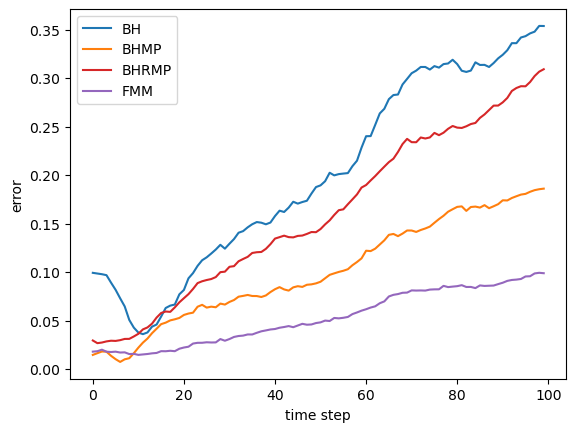

In [107]:
pointAmount = "1000"
theta = "1"
dataSet = "MNIST_digits"
perp = "30"

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBH_point"      + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHMP_point"    + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BHMP",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHR_point"     + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BHR",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHRMP_point"   + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BHRMP",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepFMM_point"     + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "FMM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepFMMiter_point" + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "FMMiter",
}

plotGraph(custom_labels, 0, 1000,"time step", "error", "plotOutput/lines_plot.png")

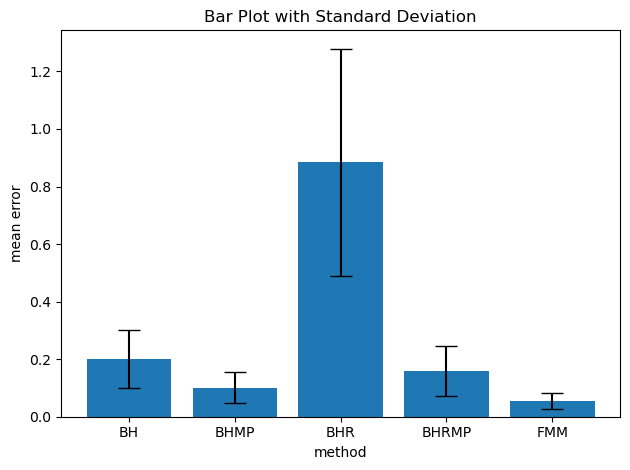

In [110]:
pointAmount = "1000"
theta = "1"
dataSet = "MNIST_digits"
perp = "30"

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBH_point"      + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHMP_point"    + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BHMP",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHR_point"     + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BHR",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepBHRMP_point"   + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "BHRMP",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepFMM_point"     + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "FMM",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorTimestepFMMiter_point" + pointAmount + "_perp" + perp + "_theta" + theta + "_dataset" + dataSet + ".csv"): "FMMiter",
}

plotBar(custom_labels, "method", "mean error", "plotOutput/lines_plot.png")

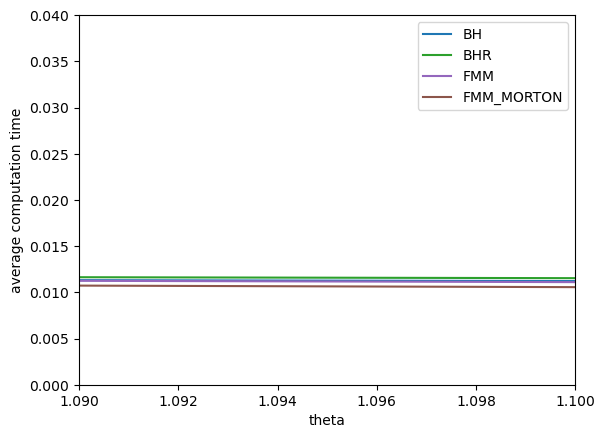

In [164]:
pointAmount = "10000"
dataSet = "MNIST_digits"
perp = "30"

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaBH_point"    + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BH",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaBHMP_point"  + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BHMP",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaBHR_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BHR",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaBHRMP_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BHRMP",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaFMM_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "FMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaFMM_MORTON_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "FMM_MORTON",
    #os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeThetaNaive_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "naive",
}

plotGraph(custom_labels, 0, 20, "theta", "average computation time", "plotOutput/lines_plot.png", False, 0.3, 1.1, 0, 0.04)

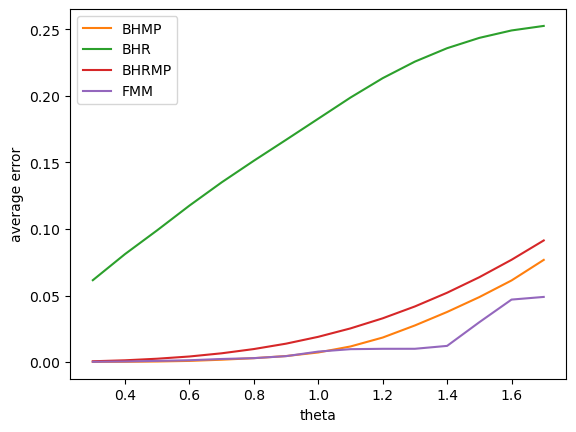

In [34]:
pointAmount = "10000"
dataSet = "MNIST_digits"
perp = "30"

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaBH_point"    + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaBHMP_point"  + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BHMP",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaBHR_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BHR",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaBHRMP_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BHRMP",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneErrorThetaFMM_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "FMM",
}

plotGraph(custom_labels, 0, 20,"theta", "average error", "plotOutput/lines_plot.png")

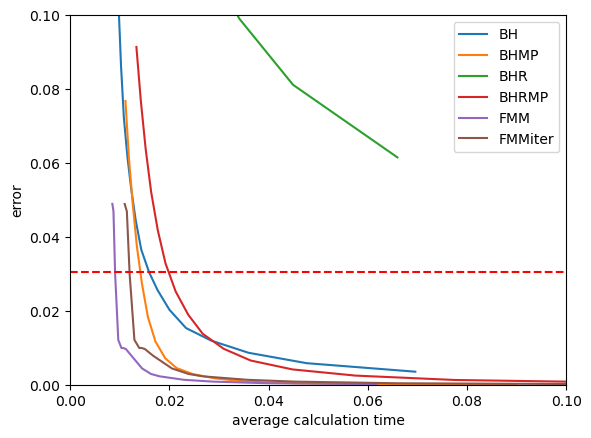

In [40]:
pointAmount = "10000"
dataSet = "MNIST_digits"
perp = "30"

allowableError = findTime(os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBH_point"    + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"))

custom_labels = {
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBH_point"      + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BH",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBHMP_point"    + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BHMP",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBHR_point"     + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BHR",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorBHRMP_point"   + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "BHRMP",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorFMM_point"     + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "FMM",
    os.path.join("graphCSV", dataSet, pointAmount, "perp" + perp, "tsneCalculationtimeErrorFMMiter_point" + pointAmount + "_perp" + perp + "_dataset" + dataSet + ".csv"): "FMMiter",
}


plotGraph(custom_labels, 0, 40, "error", "average calculation time", "plotOutput/lines_plot.png", True, 0, 0.1, 0, 0.1, allowableError, None, False)

In [ ]:
custom_labels = {
    os.path.join("graphCSV","gravityErrorTimestepBH_point1000_theta1.csv"): "BH",
    os.path.join("graphCSV","gravityErrorTimestepBHMP_point1000_theta1.csv"): "BHMP",
    os.path.join("graphCSV","gravityErrorTimestepBHR_point1000_theta1.csv"): "BHR",
    os.path.join("graphCSV","gravityErrorTimestepBHRMP_point1000_theta1.csv"): "BHRMP",
    os.path.join("graphCSV","gravityErrorTimestepFMM_point1000_theta1.csv"): "FMM",
}


plotGraph(custom_labels, 0, 1000, "time step", "error", "plotOutput/lines_plot.png")

In [ ]:
custom_labels = {
    os.path.join("graphCSV","gravityErrorTimestepCompareFMM_point500_theta1.csv"): "FMM",
    os.path.join("graphCSV","gravityErrorTimestepCompareFMMnaive_point500_theta1.csv"): "FMMnaive",
}

plotGraph(custom_labels, 0, 500, "time step", "error", "plotOutput/lines_plot.png")

In [ ]:
custom_labels = {
    os.path.join("graphCSV","gravityCalculationtimeThetaBH_point1000.csv"): "BH",
    os.path.join("graphCSV","gravityCalculationtimeThetaBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","gravityCalculationtimeThetaBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","gravityCalculationtimeThetaBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","gravityCalculationtimeThetaFMM_point1000.csv"): "FMM",
    os.path.join("graphCSV","gravityCalculationtimeThetaNaive_point1000.csv"): "naive",
}

plotGraph(custom_labels, 0, 10, "theta", "average computation time", "plotOutput/lines_plot.png")

In [ ]:
custom_labels = {
    os.path.join("graphCSV","gravityErrorThetaBH_point1000.csv"): "BH",
    os.path.join("graphCSV","gravityErrorThetaBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","gravityErrorThetaBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","gravityErrorThetaBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","gravityErrorThetaFMM_point1000.csv"): "FMM",
}

plotGraph(custom_labels, 0, 55,"theta", "average error", "plotOutput/lines_plot.png")

In [ ]:
allowableError = findTime(os.path.join("graphCSV","gravityCalculationtimeErrorBH_point1000.csv"))

custom_labels = {
    os.path.join("graphCSV","gravityCalculationtimeErrorBH_point1000.csv"): "BH",
    os.path.join("graphCSV","gravityCalculationtimeErrorBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","gravityCalculationtimeErrorBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","gravityCalculationtimeErrorBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","gravityCalculationtimeErrorFMM_point1000.csv"): "FMM",
}


plotGraph(custom_labels, 0, 40,"error", "average calculation time", "plotOutput/lines_plot.png", True, 0, 0.005, 0, 0.012, allowableError)